In [8]:
import pandas as pd
import numpy as np
import datetime

In [9]:
df=pd.read_csv('supply_chain_data.csv')

In [10]:
df.head()

,Order_ID,Order_Date,Supplier,Transport_Mode,Weather,Distance_KM,Scheduled_Lead_Time,Actual_Lead_Time
0,ORD_0001,2024-04-12,Supplier_C,Road,Clear,2010,7.0,10.0
1,ORD_0002,2025-03-11,Supplier_C,Sea,Clear,4149,12.0,17.0
2,ORD_0003,2024-12-14,Supplier_A,Sea,Stormy,2742,9.0,16.0
3,ORD_0004,2024-09-27,Supplier_C,Air,Rainy,1403,6.0,11.0
4,ORD_0005,2024-04-16,Supplier_A,Sea,Clear,231,3.0,5.0


In [11]:
df.groupby('Transport_Mode')['Actual_Lead_Time'].mean()

Transport_Mode
Air      9.309268
Road     9.830957
Sea     10.426156
Name: Actual_Lead_Time, dtype: float64

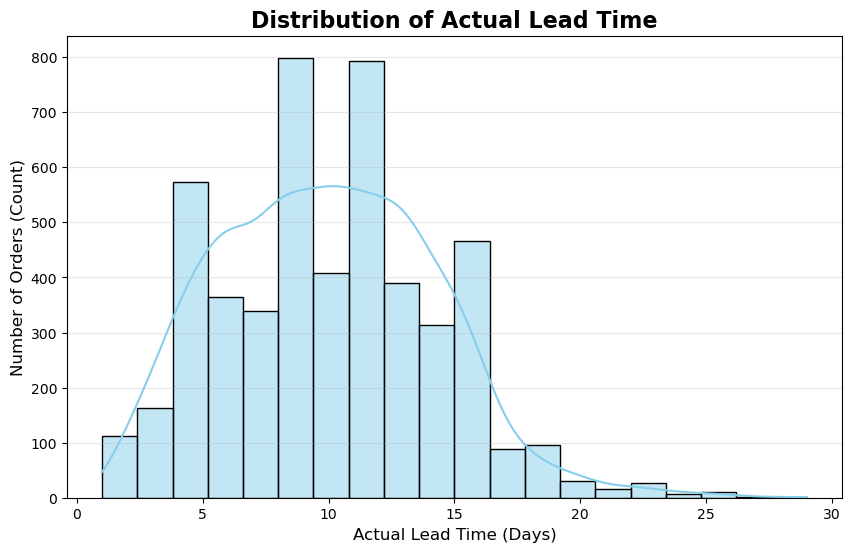

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histogram's Size
plt.figure(figsize=(10, 6))

# 2. using Seaborn draw the histogram
# beacause of kde=True  ,(Density Curve) shown
sns.histplot(df['Actual_Lead_Time'], kde=True, bins=20, color='skyblue', edgecolor='black')

# 3.labels
plt.title('Distribution of Actual Lead Time', fontsize=16, fontweight='bold')
plt.xlabel('Actual Lead Time (Days)', fontsize=12)
plt.ylabel('Number of Orders (Count)', fontsize=12)

# 4. for grid lines(optional)
plt.grid(axis='y', alpha=0.3)

# 5 show
plt.show()

In [17]:

df['Order_Date'] = pd.to_datetime(df['Order_Date'])


df['Month'] = df['Order_Date'].dt.month


df['Day'] = df['Order_Date'].dt.day

In [14]:
df[['Order_Date','Month','Day']].head()

,Order_Date,Month,Day
0,2024-04-12,4,12
1,2025-03-11,3,11
2,2024-12-14,12,14
3,2024-09-27,9,27
4,2024-04-16,4,16


In [18]:
import pandas as pd
data=['Supplier','Transport_Mode','Weather']
pd.get_dummies(data)

,Supplier,Transport_Mode,Weather
0,True,False,False
1,False,True,False
2,False,False,True


In [33]:

cols_to_drop = ['Order_ID', 'Order_Date', 'Actual_Lead_Time']


existing_cols_to_drop = [col for col in cols_to_drop if col in df_encoded.columns]
X = df_encoded.drop(columns=existing_cols_to_drop)

y = df_encoded['Actual_Lead_Time']

print("X & y are seperated successfully!")

X & y are seperated successfully!


In [34]:
from sklearn.model_selection import train_test_split

# डdata spliting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train data size: {X_train.shape}")
print(f"Train data size: {X_test.shape}")

Train data size: (4000, 5013)
Train data size: (1000, 5013)


In [44]:
!pip install xgboost

In [42]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 1.make a model object
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# 2 (Training)
model.fit(X_train, y_train)
print("XGBoost model successfully train!")

predictions = model.predict(X_test)

# 3.calculate MAPE score
mape = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"\nYour Models MAPE Score is: {mape:.2f}%")

XGBoost model successfully train!

Your Models MAPE Score is: 14.30%


In [47]:
!pip install streamlit

In [48]:
import pickle

with open('supply_chain_model.pkl', 'wb') as file:
    pickle.dump(model, file)


with open('model_columns.pkl', 'wb') as file:
    pickle.dump(X_train.columns.tolist(), file)

print("Model saved Successfully!")

Model saved Successfully!


In [ ]:
!streamlit run app.py